In [55]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import torch
import os

class quantizer_8b:
    def fit(self, a):
        kmenas = KMeans(n_clusters=2**7)
        kmeans.fit(np.abs(a).reshape(-1,1))
        self.centers = kmeans.cluster_centers_.reshape(-1)
        self.centers = np.sort(self.centers)
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
    def quantize(self,a):
        is_negative=np.sign(a)<0
        a2=np.abs(a)
        index=np.ones(a2.shape,dtype=np.int8)*(2**6-1)

        right_size = a2 > self.thresholds[index]
        
class quantizer_4b:
    
    def fit(self,a):
        kmeans = KMeans(n_clusters=8)
        kmeans.fit( np.abs(a).reshape(-1,1))
        self.centers=kmeans.cluster_centers_.reshape(-1)
        self.centers=np.sort(self.centers)
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
        
    def quantize(self,a):
        is_negative=np.sign(a)<0
        a2=np.abs(a)
        index=np.ones(a2.shape,dtype=np.int8)*3

        right_side=a2>self.thresholds[index]
        index=index-2+right_side*4
        
        right_side=a2>self.thresholds[index]
        index=index-1+right_side*2

        right_side=a2>self.thresholds[index]
        index=index+right_side
        
        index=index+8*is_negative
        return index
    
    def decode(self,index):
        return self.centers[index]
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::2]*16+ind[:,1::2]
        return comp.astype(np.uint8)

    def load_decode(self,data):
        ind=np.zeros((data.shape[0],data.shape[1]*2),dtype=np.uint8)
        ind[:,0::2]=data//16
        ind[:,1::2]=data% 16
        return self.decode(ind)
    
    def save_model(self, path):
        self.centers[:8].tofile(os.path.join(path, '4b_positive_centers'))
    def load_model(self, path):
        self.centers = np.fromfile(os.path.join(path, '4b_positive_centers'), dtype=np.float64)
        assert self.centers.shape[0] == 8
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
        
class quantizer_2b:
    
    def fit(self,a):
        kmeans = KMeans(n_clusters=2)
        kmeans.fit( np.abs(a).reshape(-1,1))
        self.centers=kmeans.cluster_centers_.reshape(-1)
        self.centers=np.sort(self.centers)
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
        
    def quantize(self,a):
        is_negative=np.sign(a)<0
        a2=np.abs(a)
        index=np.ones(a2.shape,dtype=np.int8)*0

        right_side=a2>self.thresholds[index]
        index=index+right_side
        
        index=index+2*is_negative
        return index
    
    def decode(self,index):
        return self.centers[index]
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::4]*64+ind[:,1::4]*16+ind[:,2::4]*4+ind[:,3::4]*1
        return comp.astype(np.uint8)

    def load_decode(self,data):
        ind=np.zeros((data.shape[0],data.shape[1]*4),dtype=np.uint8)
        ind[:,0::4]=(data//64)%4
        ind[:,1::4]=(data//16)%4
        ind[:,2::4]=(data// 4)%4
        ind[:,3::4]=(data// 1)%4
        return self.decode(ind)
    def save_model(self, path):
        self.centers[:2].tofile(os.path.join(path, '2b_positive_centers'))
    def load_model(self, path):
        self.centers = np.fromfile(os.path.join(path, '2b_positive_centers'), dtype=np.float32)
        assert self.centers.shape[0] == 2
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
class quantizer_1b:
    
    def fit(self,a):
        meana=np.mean(np.abs(a))
        self.centers=np.array([meana,-meana])
        
    def quantize(self,a):
        is_negative=np.sign(a)<0
        return (is_negative).astype(np.uint8)
    
    def decode(self,index):
        return self.centers[index]
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::8]*128+ind[:,1::8]* 64+ind[:,2::8]* 32+ind[:,3::8]* 16+ind[:,4::8]*  8+ind[:,5::8]*  4+ind[:,6::8]*  2+ind[:,7::8]*  1
        return comp.astype(np.uint8)

    def load_decode(self,data):
        ind=np.zeros((data.shape[0],data.shape[1]*8),dtype=np.uint8)
        ind[:,0::8]=(data//128)%2
        ind[:,1::8]=(data//64)%2
        ind[:,2::8]=(data//32)%2
        ind[:,3::8]=(data//16)%2
        ind[:,4::8]=(data// 8)%2
        ind[:,5::8]=(data// 4)%2
        ind[:,6::8]=(data// 2)%2
        ind[:,7::8]=(data// 1)%2
        return self.decode(ind)
    def save_model(self, path):
        self.centers[0:1].tofile(os.path.join(path, '1b_positive_centers'))
    def load_model(self, path):
        self.centers = np.fromfile(os.path.join(path, '1b_positive_centers'), dtype=np.float32)
        assert self.centers.shape[0] == 1
        self.centers=np.concatenate([self.centers,-self.centers])    
class quantizer_mixed:
    
    def fit(self,a, proportions=None):
        if proportions is None:
            self.proportion_4b=1/8
            self.proportion_2b=4/8
            self.proportion_1b=3/8
        else:
            self.proportion_4b, self.proportion_2b, self.proportion_1b = proportions
            
        self.count_4b=np.round(self.proportion_4b*a.shape[1]).astype(np.int32)
        self.count_2b=np.round(self.proportion_2b*a.shape[1]).astype(np.int32)
        self.count_1b=np.round(self.proportion_1b*a.shape[1]).astype(np.int32)
        self.q4=quantizer_4b()
        self.q2=quantizer_2b()
        self.q1=quantizer_1b()
        
        self.q4.fit(a[:,              : self.count_4b])
        self.q2.fit(a[:, self.count_4b:-self.count_1b])
        self.q1.fit(a[:,-self.count_1b:              ])
                
    def quantize(self,a):
        a4=self.q4.quantize(a[:,              : self.count_4b])
        a2=self.q2.quantize(a[:, self.count_4b:-self.count_1b])
        a1=self.q1.quantize(a[:,-self.count_1b:              ])      
        return np.concatenate([a4,a2,a1],axis=1)
    
    def decode(self,index):
        index4=self.q4.decode(index[:,              : self.count_4b])
        index2=self.q2.decode(index[:, self.count_4b:-self.count_1b])
        index1=self.q1.decode(index[:,-self.count_1b:              ])      
        return np.concatenate([index4,index2,index1],axis=1)

    def quantize_compress(self,a):
        comp4=self.q4.quantize_compress(a[:,              : self.count_4b])
        comp2=self.q2.quantize_compress(a[:, self.count_4b:-self.count_1b])
        comp1=self.q1.quantize_compress(a[:,-self.count_1b:              ])      
        return np.concatenate([comp4,comp2,comp1],axis=1)

    def load_decode(self,comp):
        comp4=comp[:, 0                 : self.count_4b*4//8]
        comp2=comp[:, self.count_4b*4//8:-self.count_1b*1//8]
        comp1=comp[:,-self.count_1b*1//8:                   ]
        a4=self.q4.load_decode(comp4)
        a2=self.q2.load_decode(comp2)
        a1=self.q1.load_decode(comp1)
        return np.concatenate([a4,a2,a1],axis=1)
        
    def save_model(self, path):
        if not os.path.exists(path):
            print(f"Improper path {path}")
            return
        save_dir = os.path.join(path, f"{int(self.count_4b)}_{int(self.count_2b)}_{int(self.count_1b)}")
        os.makedirs(save_dir, exist_ok=True)
        self.q4.save_model(save_dir)
        self.q2.save_model(save_dir)
        self.q1.save_model(save_dir)
    def load_model(self, path):
        self.q4=quantizer_4b()
        self.q2=quantizer_2b()
        self.q1=quantizer_1b()
        self.q4.load_model(path)
        self.q2.load_model(path)
        self.q1.load_model(path)
        print(path)
        print(os.path.basename(path).split('_'))
        print(list(map(int, os.path.basename(path).split('_'))))
        self.count_4b, self.count_2b, self.count_1b = map(int, os.path.basename(path).split('_'))
        
class representation_whitening:
    
    def fit(self,a):
        self.mn=a.mean(axis=0)
        
        # low memory covariance calculation
        cov=np.zeros((a.shape[1],a.shape[1]))
        for i in range(0,a.shape[0],10000):
            aslice=torch.tensor(a[i:i+10000,:]-self.mn).to('cuda:1').to(torch.float32)
            cov+=( aslice.T@aslice).cpu().numpy()/a.shape[0]
            
        s2,self.q=np.linalg.eigh(cov)
        self.s=np.sqrt(s2)
        
        if self.s[0]<self.s[-1]:
            self.s=np.flip(self.s)
            self.q=self.q[:,::-1]+0 # add 0 to avoid negative stride error
       
    def encode(self,a):
        qgpu=torch.tensor(self.q   ).to('cuda:1').to(torch.float32)
        agpu=torch.tensor(a-self.mn).to('cuda:1').to(torch.float32)
        return (agpu@qgpu).cpu().numpy()/self.s
    
    def decode(self,e):
        qgpu=torch.tensor(self.q   ).to('cuda:1').to(torch.float32)
        egpu=torch.tensor(self.s*e ).to('cuda:1').to(torch.float32)
        return ( egpu@qgpu.T).cpu().numpy()+self.mn
    
    def rescale(self,e):
        return self.s*e


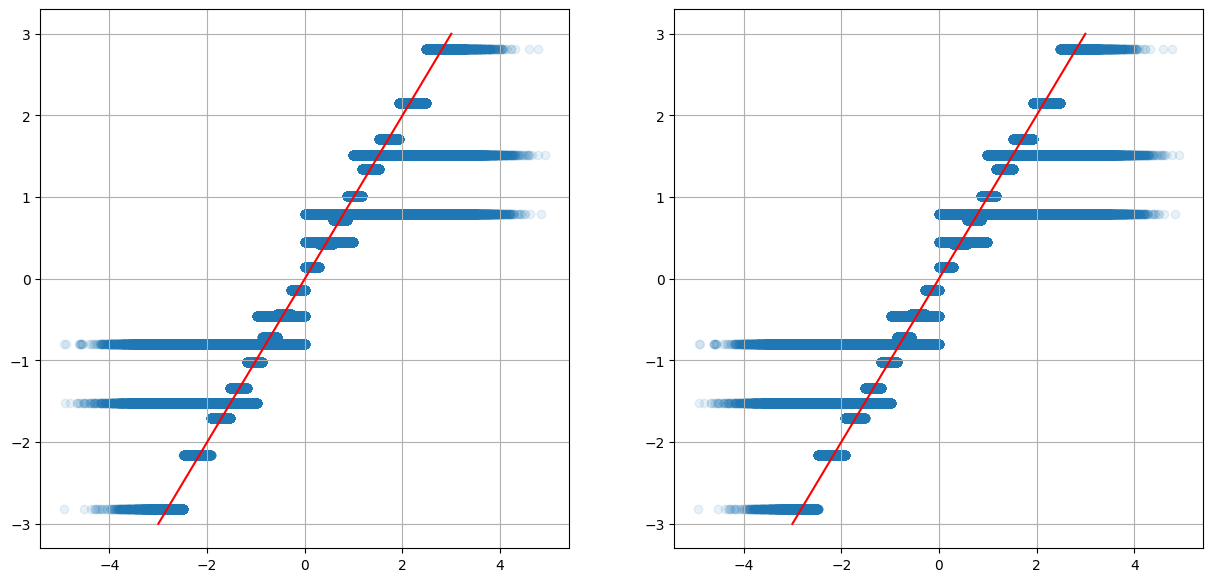

In [2]:
# test quantizer models

plt.figure(figsize=(15,7))
# fit the quantizer
a=np.random.normal(0,1,(2048,2048))
q=quantizer_mixed() # also try _1b _2b _4b
q.fit(a)

# quantize, decode, visualize
ind=q.quantize(a)
a_new=q.decode(ind)
plt.subplot(1,2,1)
plt.scatter(a,a_new,alpha=0.1)
plt.plot([-3,3],[-3,3],'r')
plt.grid()

# quantize, compress, decompress, decode, visualize
data=q.quantize_compress(a)
a_new=q.load_decode(data)
plt.subplot(1,2,2)
plt.scatter(a,a_new,alpha=0.1)
plt.plot([-3,3],[-3,3],'r')
plt.grid()

In [25]:
q=quantizer_mixed()


In [4]:
# a regular use of the classes
W=representation_whitening()

a=np.fromfile('whitening/a_big',dtype=np.float16).reshape(-1,2048).astype(np.float32)

W.fit(a)
aw=W.encode(a)


In [26]:
q.fit(aw[0:1000,:]) # a small subset of values is enough to learn quantization parameters

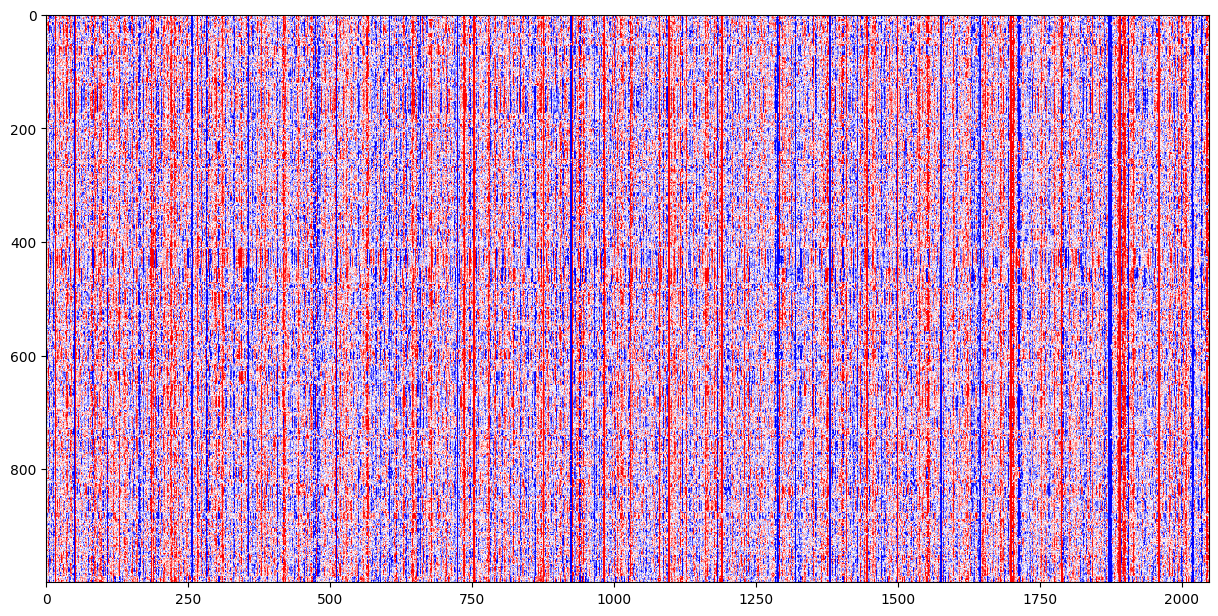

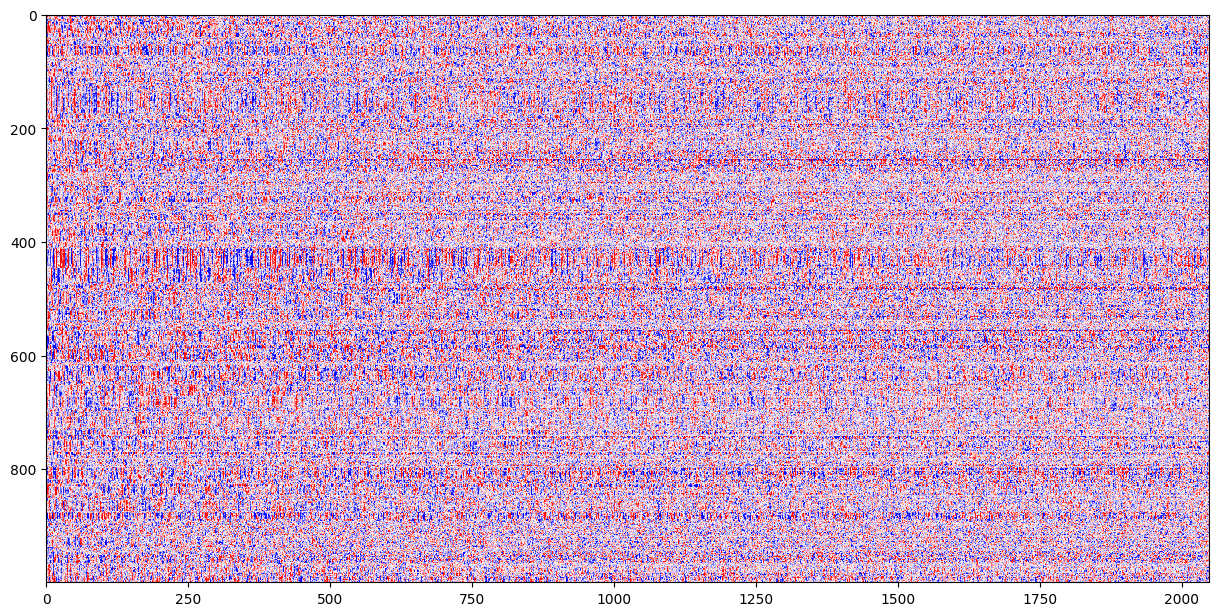

In [6]:
plt.figure(figsize=(15,15))
plt.imshow( a[0:1000,:] ,cmap='bwr',vmin=-1,vmax=1) #aw_new[0:4000,:]-
plt.figure(figsize=(15,15))
plt.imshow( aw[0:1000,:] ,cmap='bwr',vmin=-1,vmax=1) #aw_new[0:4000,:]-

In [6]:
q4 = quantizer_4b()
q4.fit(aw[0:1000,:])
data4 = q4.quantize_compress(aw)
aw_new4 = q4.load_decode(data4)
print(data4.shape)
print(a.shape)

(661621, 1024)
(661621, 2048)


In [85]:
# os.makedirs('exp2')
q1.centers[0:1].tofile('exp2/1b_positive_centers')

In [87]:
q2.centers[:2].tofile('exp3/2b_positive_centers')

In [88]:
q4.centers[:8].tofile('exp4/4b_positive_centers')

In [7]:
q2 = quantizer_2b()
q2.fit(aw[0:1000,:])
data2 = q2.quantize_compress(aw)
aw_new2 = q2.load_decode(data2)
print(data2.shape)
print(a.shape)

(661621, 512)
(661621, 2048)


In [8]:
q1 = quantizer_1b()
q1.fit(aw[0:1000,:])
data1 = q1.quantize_compress(aw)
aw_new1 = q1.load_decode(data1)
print(data1.shape)
print(a.shape)

(661621, 256)
(661621, 2048)


In [9]:
data=q.quantize_compress(aw)
aw_new=q.load_decode(data)
print(data.shape)
print(a.shape)

(661621, 480)
(661621, 2048)


In [23]:
data4.tofile('whitening/cache/big_8_0_0_1024')
data2.tofile('whitening/cache/big_0_8_0_512')
data1.tofile('whitening/cache/big_0_0_8_256')

In [12]:
data.tofile('whitening/cache/big_1_4_3_480')

In [43]:
path='whitening/exp1'
imap(int, os.path.basename(path).split('_'))f not os.path.exists(path):
    print(f"Improper path {path}")
save_dir = os.path.join(path, f"{int(q.count_4b)}_{int(q.count_2b)}_{int(q.count_1b)}")
os.makedirs(save_dir, exist_ok=True)
q.q4.save_model(save_dir)
q.q2.save_model(save_dir)
q.q1.save_model(save_dir)


In [42]:
os.makedirs('whitening/exp1', exist_ok=True)
q.save_model('whitening/exp1')

AttributeError: 'quantizer_mixed' object has no attribute 'count_4b'

In [36]:
q.q4.centers = q.q4.centers.astype(np.float32)
q.q2.centers = q.q2.centers.astype(np.float32)
q.q1.centers = q.q1.centers.astype(np.float32)

In [47]:
list(map(int, os.path.basename('whitening/exp1/256_1024_768').split('_')))

[256, 1024, 768]

In [41]:
q.save_model = qprime.save_model

In [35]:
q.q4.centers.dtype

dtype('float64')

In [33]:
np.fromfile(os.path.join('whitening/exp1/256_1024_768', '4b_positive_centers'), dtype=np.float32).shape

(16,)

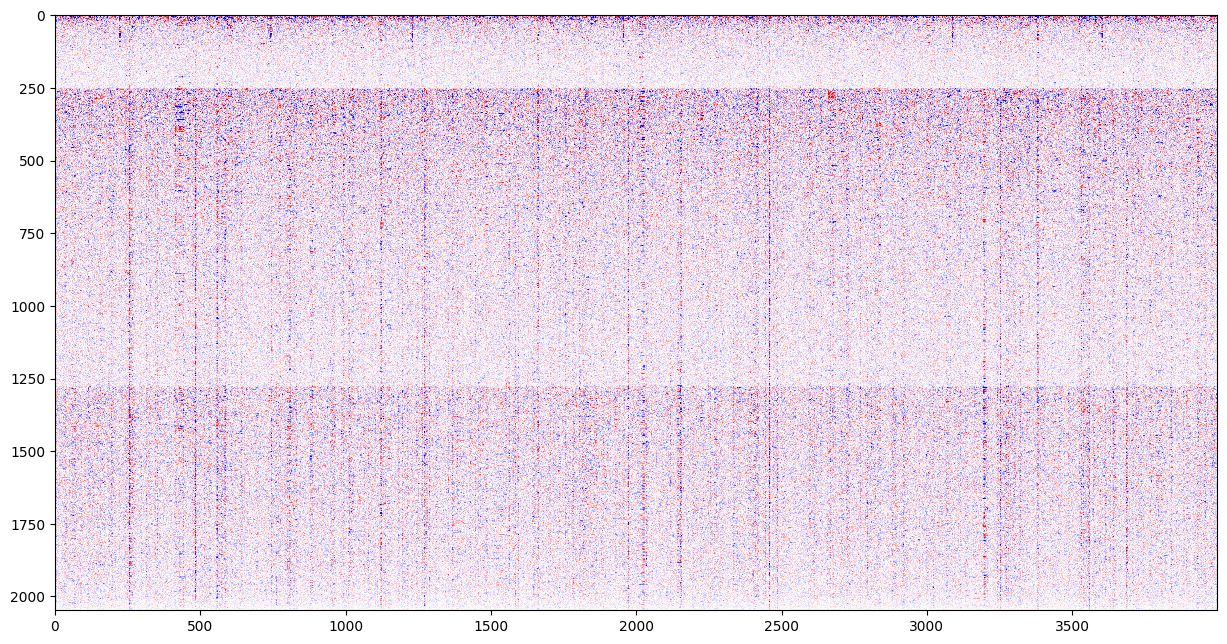

In [8]:
error=W.rescale(aw[0:4000,:])-aw_new[0:4000,:]).T
plt.figure(figsize=(15,15))
plt.imshow( error ,cmap='bwr',vmin=-0.2,vmax=0.2) #aw_new[0:4000,:]-

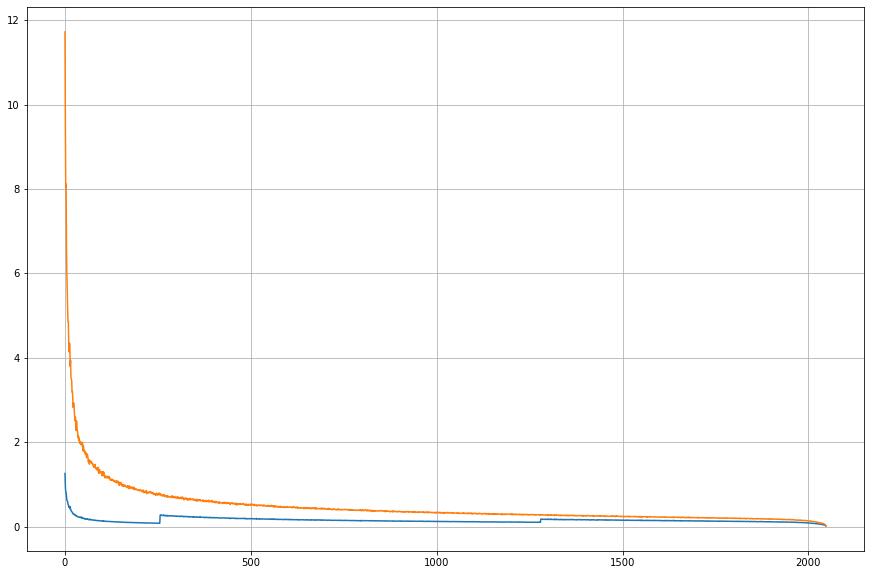

In [100]:
plt.figure(figsize=(15,10))
plt.plot( np.abs(error).mean(axis=1))
plt.plot( np.abs(W.rescale(aw[0:4000,:]).T).mean(axis=1))
plt.yscale('log')
plt.grid()